In [1]:
import numpy as np
from scipy import stats
from scipy.interpolate import griddata
import einops
import concurrent.futures
import pickle
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import hiposa
import hiposa.poisson_tiler
from hiposa.poisson_disc_sampling import PoissonDiskSamplerWithExisting
from hiposa.point_selector import PointSelector
import os

from sklearn.neighbors import NearestNeighbors
from collections import defaultdict

In [18]:
upper = 1
lower = 0
scales = (1/3) / (np.sqrt(2)**np.arange(0,5,1))

pTiler1 = hiposa.poisson_tiler.PoissonTiler(tile_size=1, spacings=scales)
xy1, levels1 = pTiler1.get_points_in_region([[lower, 1.0*upper], [lower, 1.0*upper]], add_corners=False)
total_points1 = len(xy1) 
print(f"Total points generated: {total_points1}")

pTiler2 = hiposa.poisson_tiler.PoissonTiler(tile_size=1, spacings=scales)
xy2, levels2 = pTiler2.get_points_in_region([[lower, 1.0*upper], [lower, 1.0*upper]], add_corners=False)
total_points2 = len(xy2) 
print(f"Total points generated: {total_points2}")




Initializing PoissonTiler:
Requested tile size: 1
Actual tile size: 1 (minimum required: 0.6666666666666666)
Spacings: [0.33333333 0.23570226 0.16666667 0.11785113 0.08333333]
Dimensions: 2
Tile domain: [(0, 1), (0, 1)]

Generating base tile...

Generating level 0 with spacing 0.3333333333333333
Level 0: Generated 5 points

Generating level 1 with spacing 0.2357022603955158
Level 1: Generated 6 points

Generating level 2 with spacing 0.16666666666666663
Level 2: Generated 14 points

Generating level 3 with spacing 0.11785113019775789
Level 3: Generated 20 points

Generating level 4 with spacing 0.08333333333333331
Level 4: Generated 48 points

Base tile complete with 93 total points
Total points generated: 93

Initializing PoissonTiler:
Requested tile size: 1
Actual tile size: 1 (minimum required: 0.6666666666666666)
Spacings: [0.33333333 0.23570226 0.16666667 0.11785113 0.08333333]
Dimensions: 2
Tile domain: [(0, 1), (0, 1)]

Generating base tile...

Generating level 0 with spacing 0

In [4]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from collections import defaultdict

def labeled_outer_product(xy1, xy2, labels1, labels2):
    """
    Performs an outer product between two point sets and tracks label information.
    
    Parameters:
    -----------
    xy1 : numpy.ndarray
        First array of points with shape (n_samples1, n_features).
    xy2 : numpy.ndarray
        Second array of points with shape (n_samples2, n_features).
    labels1 : numpy.ndarray
        Labels for points in xy1 with shape (n_samples1,).
    labels2 : numpy.ndarray
        Labels for points in xy2 with shape (n_samples2,).
    
    Returns:
    --------
    numpy.ndarray
        Array of generated points from the outer product with shape (n_samples1 * n_samples2, 2 * n_features).
    list of tuples
        List of paired labels for each generated point, with shape (n_samples1 * n_samples2, 2).
    """
    # Get number of samples and features
    n_samples1, n_features1 = xy1.shape
    n_samples2, n_features2 = xy2.shape
    
    # Ensure labels have correct shapes
    assert labels1.shape == (n_samples1,), "labels1 must have shape (n_samples1,)"
    assert labels2.shape == (n_samples2,), "labels2 must have shape (n_samples2,)"
    
    # Initialize results
    n_output = n_samples1 * n_samples2
    out_features = n_features1 + n_features2
    output_points = np.zeros((n_output, out_features))
    output_labels = []
    
    # Perform outer product
    idx = 0
    for i in range(n_samples1):
        for j in range(n_samples2):
            # Concatenate features from both points
            output_points[idx, :n_features1] = xy1[i]
            output_points[idx, n_features1:] = xy2[j]
            
            # Track label pair
            output_labels.append((labels1[i], labels2[j]))
            
            idx += 1
    
    return output_points, output_labels

def compute_simple_nn_stats(xy, labels, n_neighbors=5, metric='euclidean'):
    """
    Compute simplified min, max, and mean statistics for nearest neighbors conditioned on their labels.
    
    Parameters:
    -----------
    xy : numpy.ndarray
        Array of shape (n_samples, n_features) containing the input points.
    labels : list of tuples or numpy.ndarray
        Labels for each point. Can be a list of tuples or a simple array.
    n_neighbors : int, default=5
        Number of nearest neighbors to consider for each point.
    metric : str, default='euclidean'
        Distance metric to use for the nearest neighbors computation.
        
    Returns:
    --------
    dict
        A dictionary where keys are tuples (label_from, label_to) and values
        are dictionaries containing min, max, and mean distances.
    dict
        A count dictionary showing how many connections exist between each label pair.
    """
    # Initialize nearest neighbors model
    nn = NearestNeighbors(n_neighbors=n_neighbors+1, metric=metric)
    nn.fit(xy)
    
    # Find nearest neighbors for each point (including itself)
    distances, indices = nn.kneighbors(xy)
    
    # Initialize dictionaries to store results
    stats = defaultdict(lambda: {'min': float('inf'), 'max': 0, 'sum': 0, 'count': 0})
    connection_counts = defaultdict(int)
    
    # Get unique labels to ensure we track all possible label pairs
    unique_labels = list(set(labels))
    
    # First, initialize entries for all possible label pairs
    # This ensures we track (0,0)->(0,0) and other same-label connections
    for label_from in unique_labels:
        for label_to in unique_labels:
            label_pair = (label_from, label_to)
            stats[label_pair] = {'min': float('inf'), 'max': 0, 'sum': 0, 'count': 0}
            connection_counts[label_pair] = 0
    
    # Process each point
    for i in range(len(xy)):
        label_from = labels[i]
        
        # Skip the first neighbor (which is the point itself)
        for j in range(1, n_neighbors+1):
            neighbor_idx = indices[i, j]
            label_to = labels[neighbor_idx]
            distance = distances[i, j]
            
            # Update statistics for this label pair
            label_pair = (label_from, label_to)
            stats[label_pair]['min'] = min(stats[label_pair]['min'], distance)
            stats[label_pair]['max'] = max(stats[label_pair]['max'], distance)
            stats[label_pair]['sum'] += distance
            stats[label_pair]['count'] += 1
            connection_counts[label_pair] += 1
    
    # Calculate means and handle edge cases
    for label_pair in stats:
        if stats[label_pair]['count'] > 0:
            stats[label_pair]['mean'] = stats[label_pair]['sum'] / stats[label_pair]['count']
            # Reset infinity to a more sensible value for empty cases
            if stats[label_pair]['min'] == float('inf'):
                stats[label_pair]['min'] = 0.0
        else:
            # No connections found for this label pair
            stats[label_pair]['min'] = 0.0
            stats[label_pair]['max'] = 0.0
            stats[label_pair]['mean'] = 0.0
            
        del stats[label_pair]['sum']  # Remove the sum as we don't need it anymore
    
    # Convert defaultdicts to regular dicts
    stats = dict(stats)
    connection_counts = dict(connection_counts)
    
    return stats, connection_counts

def outer_product_simple_nn_stats(xy1, xy2, labels1, labels2, n_neighbors=5, metric='euclidean'):
    """
    Combines the labeled outer product with simplified nearest neighbor statistics.
    
    This function first creates an outer product of two point sets while preserving their
    label information, then computes min, max, and mean distances between nearest neighbors
    conditioned on the combined label pairs.
    
    Parameters:
    -----------
    xy1 : numpy.ndarray
        First array of points with shape (n_samples1, n_features).
    xy2 : numpy.ndarray
        Second array of points with shape (n_samples2, n_features).
    labels1 : numpy.ndarray
        Labels for points in xy1 with shape (n_samples1,).
    labels2 : numpy.ndarray
        Labels for points in xy2 with shape (n_samples2,).
    n_neighbors : int, default=5
        Number of nearest neighbors to consider for each point.
    metric : str, default='euclidean'
        Distance metric to use for the nearest neighbors computation.
        
    Returns:
    --------
    dict
        A dictionary where keys are tuples ((from_label1, from_label2), (to_label1, to_label2))
        and values are dictionaries containing min, max, and mean distances.
    dict
        A count dictionary showing how many connections exist between each label pair.
    list of tuples
        The list of combined labels from the outer product.
    numpy.ndarray
        The combined points from the outer product.
    """
    # First, generate the outer product
    combined_points, combined_labels = labeled_outer_product(xy1, xy2, labels1, labels2)
    
    # Compute simplified nearest neighbor statistics using the combined labels
    stats, counts = compute_simple_nn_stats(
        combined_points, combined_labels, n_neighbors, metric
    )
    
    return stats, counts, combined_labels, combined_points



In [19]:
tmp = outer_product_simple_nn_stats(xy1, xy2, levels1, levels2, n_neighbors=30, metric='euclidean')

In [20]:
ds = []
for key in tmp[0].keys():
    if tmp[0][key]['count'] > 0:
        ds.append(tmp[0][key]['min'])
        print(key, tmp[0][key])
        

((4, 0), (4, 0)) {'min': 0.0838934339863841, 'max': 0.22945608744317286, 'count': 847, 'mean': 0.14059715674002904}
((4, 0), (3, 4)) {'min': 0.11932143443407624, 'max': 0.22582518197899068, 'count': 703, 'mean': 0.15162502839632813}
((4, 0), (4, 3)) {'min': 0.11992194466028407, 'max': 0.24783647161216737, 'count': 725, 'mean': 0.16140225892039156}
((4, 0), (0, 2)) {'min': 0.19031494462758003, 'max': 0.2059321156783114, 'count': 6, 'mean': 0.19792483625949273}
((4, 0), (2, 2)) {'min': 0.192323198294847, 'max': 0.21413833386509964, 'count': 12, 'mean': 0.20497629078587054}
((4, 0), (1, 0)) {'min': 0.08430180479455279, 'max': 0.16743437583711404, 'count': 119, 'mean': 0.10916677519620353}
((4, 0), (1, 3)) {'min': 0.14658808649656055, 'max': 0.21993204304374178, 'count': 110, 'mean': 0.17330390851764185}
((4, 0), (4, 2)) {'min': 0.1707198499730347, 'max': 0.2212989354834967, 'count': 150, 'mean': 0.18175291933688326}
((4, 0), (3, 0)) {'min': 0.08536553782451096, 'max': 0.2111433485669339, 

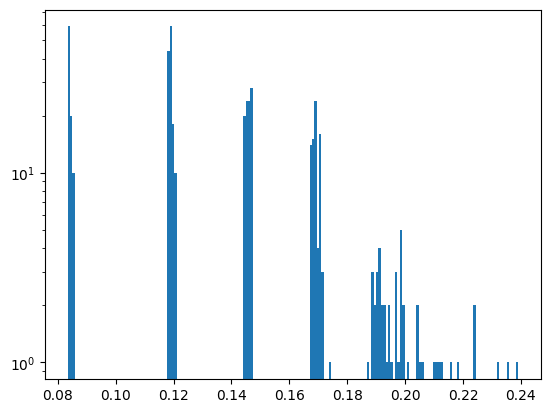

In [21]:
plt.hist(np.array(ds), bins=190)
plt.yscale('log')
plt.show()

In [24]:
xy_12, l_12 = labeled_outer_product(xy1, xy2, levels1, levels2)

In [25]:
N = len(xy_12)
print(N)

8463


In [22]:
def minimum_distance_periodic(point1, point2, box_size=1):
    """
    Calculate the minimum distance between two points in a periodic N-dimensional cube.
    
    Parameters:
    point1, point2: arrays of shape (N,) representing coordinates in N dimensions
    box_size: float or array of shape (N,) representing the size of the periodic box in each dimension
    
    Returns:
    min_distance: float, the minimum distance considering periodicity
    """
    # Convert inputs to numpy arrays
    point1 = np.array(point1)
    point2 = np.array(point2)
    
    # Handle both scalar and array-like box_size
    if np.isscalar(box_size):
        box_size = np.full_like(point1, box_size)
    else:
        box_size = np.array(box_size)
    
    # Calculate direct distance vector
    delta = np.abs(point2 - point1)
    
    # Apply minimum image convention for each dimension
    # This finds the shortest distance considering periodicity
    delta = np.minimum(delta, box_size - delta)
    
    # Calculate Euclidean distance
    min_distance = np.sqrt(np.sum(delta**2))
    
    return min_distance

In [26]:
def max_rule(label):
    return np.max(np.array(label))

def sum_rule(label):
    return np.sum(np.array(label))
    
    
min_dist_dict = {}

for i in range(N):
    for j in range(i+1, N):
        txy1 = xy_12[i]
        txy2 = xy_12[j]
        tl2 = l_12[i] 
        tl1 = l_12[j]
        dd = minimum_distance_periodic(txy1, txy2)
        
        combined_label = (tl1[0], tl1[1], tl2[0], tl2[1])
        if combined_label not in min_dist_dict:
            min_dist_dict[combined_label] = dd
        else:
            if dd < min_dist_dict[combined_label]:
                min_dist_dict[combined_label] = dd

        combined_label = (tl2[0], tl2[1], tl1[0], tl1[1])
        if combined_label not in min_dist_dict:
            min_dist_dict[combined_label] = dd
        else:
            if dd < min_dist_dict[combined_label]:
                min_dist_dict[combined_label] = dd

        
    if i%500==0:
        print(min_dist_dict)






        

{(0, 0, 0, 0): 0.34583527592159263, (0, 1, 0, 0): 0.26436201645548757, (0, 0, 0, 1): 0.26436201645548757, (0, 2, 0, 0): 0.1707198499730347, (0, 0, 0, 2): 0.1707198499730347, (0, 3, 0, 0): 0.12234642961956883, (0, 0, 0, 3): 0.12234642961956883, (0, 4, 0, 0): 0.08717216947121036, (0, 0, 0, 4): 0.08717216947121036, (1, 0, 0, 0): 0.24449616593616716, (0, 0, 1, 0): 0.24449616593616716, (1, 1, 0, 0): 0.3600911702637226, (0, 0, 1, 1): 0.3600911702637226, (1, 2, 0, 0): 0.29820067460068106, (0, 0, 1, 2): 0.29820067460068106, (1, 3, 0, 0): 0.27339901974612474, (0, 0, 1, 3): 0.27339901974612474, (1, 4, 0, 0): 0.25957149744878233, (0, 0, 1, 4): 0.25957149744878233, (2, 0, 0, 0): 0.1669830106574024, (0, 0, 2, 0): 0.1669830106574024, (2, 1, 0, 0): 0.3126829090190598, (0, 0, 2, 1): 0.3126829090190598, (2, 2, 0, 0): 0.23880660171575163, (0, 0, 2, 2): 0.23880660171575163, (2, 3, 0, 0): 0.20700718511410723, (0, 0, 2, 3): 0.20700718511410723, (2, 4, 0, 0): 0.1883674944849232, (0, 0, 2, 4): 0.188367494484

In [28]:
vals = []
for _ in min_dist_dict:
    vals.append(min_dist_dict[_])

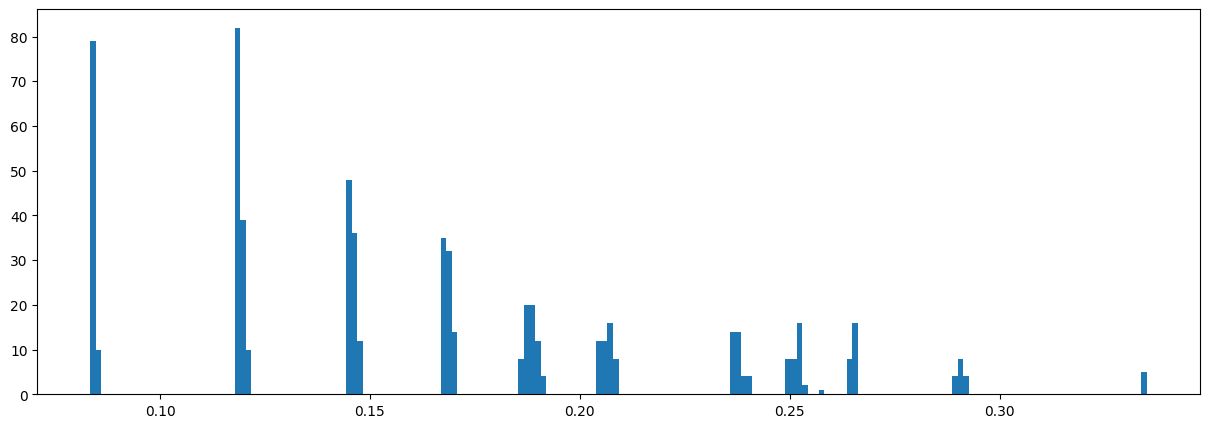

In [29]:
plt.figure(figsize=(15,5))
plt.hist(vals, bins=190)
plt.show()

Detected peak ranges:
Peak 1: 0.08 to 0.09
Peak 2: 0.11 to 0.12
Peak 3: 0.14 to 0.15
Peak 4: 0.16 to 0.17
Peak 5: 0.18 to 0.19
Peak 6: 0.20 to 0.21
Peak 7: 0.23 to 0.24
Peak 8: 0.25 to 0.26
Peak 9: 0.26 to 0.27
Peak 10: 0.29 to 0.29
Peak 11: 0.33 to 0.34


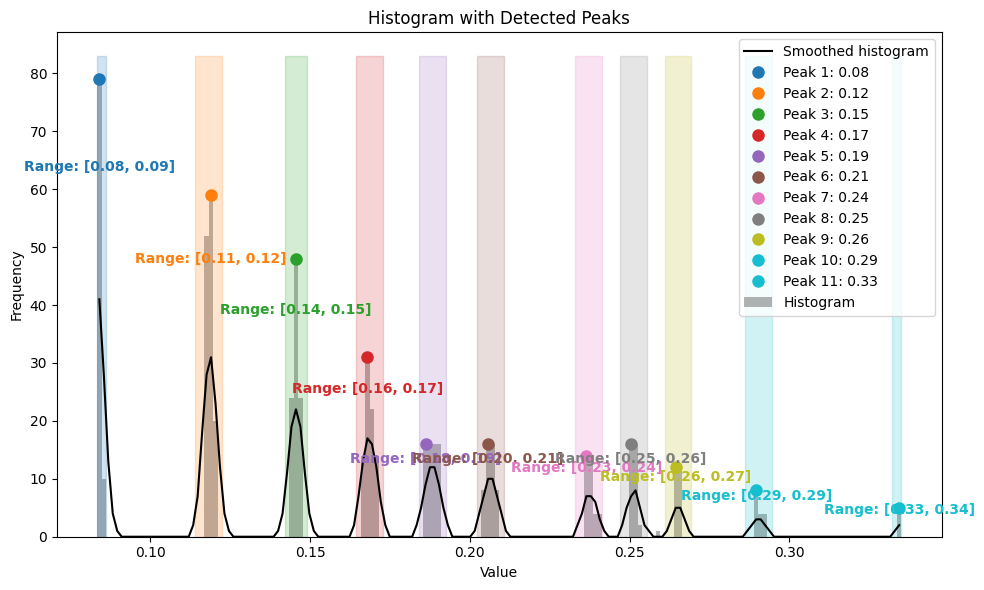

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths
from scipy.ndimage import gaussian_filter1d

def find_histogram_peaks(hist_values, bin_edges, prominence=None, width=None, 
                         height=None, distance=None, smooth_sigma=None,
                         check_endpoints=True):
    """
    Find peaks in histogram data and their x-ranges, including potential peaks
    at the beginning and end of the data range.
    
    Parameters:
    -----------
    hist_values : array
        The histogram values (y-axis)
    bin_edges : array
        The bin edges from histogram (has length len(hist_values) + 1)
    prominence : float, optional
        Required prominence of peaks
    width : float, optional
        Required width of peaks
    height : float, optional
        Required height of peaks
    distance : float, optional
        Required minimum horizontal distance between peaks
    smooth_sigma : float, optional
        Sigma for Gaussian smoothing (None for no smoothing)
    check_endpoints : bool, optional
        Whether to check for peaks at the beginning and end of the range
        
    Returns:
    --------
    peak_indices : array
        Indices of peak locations
    peak_ranges : list of tuples
        List of (start_x, end_x) for each peak
    """
    # Convert bin edges to bin centers for plotting
    bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
    
    # Optional: smooth the histogram data
    if smooth_sigma is not None:
        hist_values_smooth = gaussian_filter1d(hist_values, smooth_sigma)
    else:
        hist_values_smooth = hist_values
    
    # Find peaks using scipy's find_peaks
    peak_indices, properties = find_peaks(hist_values_smooth, prominence=prominence,
                                         width=width, height=height, distance=distance)
    
    # Find peak widths at half prominence
    widths, width_heights, left_ips, right_ips = peak_widths(hist_values_smooth, 
                                                           peak_indices, rel_height=0.5)
    
    # Check for endpoint peaks if requested
    if check_endpoints:
        # Check if the first point might be a peak (rising edge at beginning)
        endpoint_peaks_to_add = []
        endpoint_ranges_to_add = []
        
        # Check left endpoint
        left_endpoint_height = hist_values_smooth[0]
        if left_endpoint_height > 0:
            # Check if it's higher than the next few points (suggesting it's the start of a peak)
            window_size = min(5, len(hist_values_smooth) // 10)  # Look at ~10% of the data or 5 points
            if np.all(left_endpoint_height >= hist_values_smooth[1:window_size]):
                # If there's a significant local maximum near the start
                # or the start is higher than a threshold, consider it a peak
                min_height = left_endpoint_height * 0.5 if prominence is None else prominence
                lookforward = min(len(hist_values_smooth) // 3, 20)  # Look forward up to 20 points or 1/3 of data
                
                # Find where the value drops below half the height
                for i in range(1, lookforward):
                    if i >= len(hist_values_smooth) or hist_values_smooth[i] < left_endpoint_height - min_height:
                        # Found the right edge of this potential starting peak
                        endpoint_peaks_to_add.append(0)  # Add index 0 as a peak
                        endpoint_ranges_to_add.append((bin_edges[0], bin_edges[i+1]))
                        break
        
        # Check right endpoint
        right_endpoint_height = hist_values_smooth[-1]
        if right_endpoint_height > 0:
            window_size = min(5, len(hist_values_smooth) // 10)
            if np.all(right_endpoint_height >= hist_values_smooth[-window_size:-1]):
                min_height = right_endpoint_height * 0.5 if prominence is None else prominence
                lookback = min(len(hist_values_smooth) // 3, 20)
                
                # Find where the value drops below half the height
                for i in range(1, lookback):
                    if i >= len(hist_values_smooth) or hist_values_smooth[-i-1] < right_endpoint_height - min_height:
                        # Found the left edge of this potential ending peak
                        endpoint_peaks_to_add.append(len(hist_values_smooth) - 1)
                        endpoint_ranges_to_add.append((bin_edges[-i-2], bin_edges[-1]))
                        break
        
        # Combine regular peaks with endpoint peaks
        if endpoint_peaks_to_add:
            peak_indices = np.append(peak_indices, endpoint_peaks_to_add)
            
            # Convert regular peak boundaries to x values before combining
            peak_ranges = []
            for left_ip, right_ip in zip(left_ips, right_ips):
                # Convert fractional indices to bin values
                left_idx = int(np.floor(left_ip))
                right_idx = int(np.ceil(right_ip))
                
                # Handle edge cases
                left_idx = max(0, left_idx)
                right_idx = min(len(bin_centers) - 1, right_idx)
                
                # Get x values
                start_x = bin_edges[left_idx]
                end_x = bin_edges[right_idx + 1]  # +1 because we want the right edge
                
                peak_ranges.append((start_x, end_x))
            
            # Add endpoint peak ranges
            peak_ranges.extend(endpoint_ranges_to_add)
            
            # Sort peaks and ranges by x position
            sort_indices = np.argsort(np.append(bin_centers[peak_indices[:-len(endpoint_peaks_to_add)]], 
                                              [r[0] for r in endpoint_ranges_to_add]))
            peak_indices = np.append(peak_indices[:-len(endpoint_peaks_to_add)], 
                                     endpoint_peaks_to_add)[sort_indices]
            peak_ranges = [peak_ranges[i] for i in sort_indices]
            
        else:
            # Convert regular peak boundaries to x values
            peak_ranges = []
            for left_ip, right_ip in zip(left_ips, right_ips):
                # Convert fractional indices to bin values
                left_idx = int(np.floor(left_ip))
                right_idx = int(np.ceil(right_ip))
                
                # Handle edge cases
                left_idx = max(0, left_idx)
                right_idx = min(len(bin_centers) - 1, right_idx)
                
                # Get x values
                start_x = bin_edges[left_idx]
                end_x = bin_edges[right_idx + 1]  # +1 because we want the right edge
                
                peak_ranges.append((start_x, end_x))
    else:
        # Original conversion code from the previous version
        peak_ranges = []
        for left_ip, right_ip in zip(left_ips, right_ips):
            left_idx = int(np.floor(left_ip))
            right_idx = int(np.ceil(right_ip))
            
            left_idx = max(0, left_idx)
            right_idx = min(len(bin_centers) - 1, right_idx)
            
            start_x = bin_edges[left_idx]
            end_x = bin_edges[right_idx + 1]
            
            peak_ranges.append((start_x, end_x))
    
    return peak_indices, peak_ranges, bin_centers, hist_values_smooth

def plot_histogram_with_peaks(x_data, bins=50, **peak_kwargs):
    """
    Create a histogram, find peaks, and plot them with highlights.
    
    Parameters:
    -----------
    x_data : array
        Raw data to create histogram from
    bins : int or array
        Number of bins or bin edges for histogram
    **peak_kwargs : 
        Keyword arguments passed to find_histogram_peaks
    """
    # Create histogram
    hist_values, bin_edges = np.histogram(x_data, bins=bins)
    
    # Find peaks and their ranges
    peak_indices, peak_ranges, bin_centers, hist_smooth = find_histogram_peaks(
        hist_values, bin_edges, **peak_kwargs)
    
    # Set up plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot the histogram
    ax.bar(bin_centers, hist_values, width=bin_centers[1]-bin_centers[0], 
           alpha=0.6, color='gray', label='Histogram')
    
    # Plot the smoothed line if smoothing was applied
    if peak_kwargs.get('smooth_sigma') is not None:
        ax.plot(bin_centers, hist_smooth, color='black', linestyle='-', 
                label='Smoothed histogram')
    
    # Highlight peak regions with different colors
    colors = plt.cm.tab10(np.linspace(0, 1, len(peak_ranges)))
    
    for i, ((start_x, end_x), color) in enumerate(zip(peak_ranges, colors)):
        # Find all bins that fall within this peak's range
        mask = (bin_centers >= start_x) & (bin_centers <= end_x)
        
        # Create a rectangle for the peak region
        rect = plt.Rectangle((start_x, 0), end_x - start_x, max(hist_values) * 1.05,
                           alpha=0.2, color=color)
        ax.add_patch(rect)
        
        # Find the highest point in this range for labeling
        if any(mask):
            masked_values = hist_values[mask]
            max_idx = np.argmax(masked_values)
            peak_x = bin_centers[mask][max_idx]
            peak_y = masked_values[max_idx]
        else:
            # If no bins fall within range (unlikely but possible with very narrow peaks)
            mid_x = (start_x + end_x) / 2
            idx = np.argmin(np.abs(bin_centers - mid_x))
            peak_x = bin_centers[idx]
            peak_y = hist_values[idx]
        
        # Mark the peak
        ax.plot(peak_x, peak_y, 'o', color=color, 
                markersize=8, label=f'Peak {i+1}: {peak_x:.2f}')
        
        # Add text label for the range
        ax.text(peak_x, peak_y * 0.8, 
                f'Range: [{start_x:.2f}, {end_x:.2f}]', 
                ha='center', color=color, fontweight='bold')
    
    # Add labels and legend
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.set_title('Histogram with Detected Peaks')
    ax.legend()
    
    plt.tight_layout()
    return fig, ax, peak_ranges

if True:
    fig, ax, peak_ranges = plot_histogram_with_peaks(
        vals, 
        bins=180,
        prominence=0.5,   # Adjust based on your histogram scale
        width=None,      # Minimum width (in bins)
        height=None,     # Minimum height
        distance=5,      # Minimum distance between peaks (in bins)
        smooth_sigma=1.5, # Smoothing factor
        check_endpoints=True  # Look for peaks at endpoints
    )
    
    print("Detected peak ranges:")
    for i, (start, end) in enumerate(peak_ranges):
        print(f"Peak {i+1}: {start:.2f} to {end:.2f}")
    
    plt.show()

In [38]:
print(peak_ranges)

[(0.08336863719251708, 0.08616522660836505), (0.11413112076684477, 0.12252088901438868), (0.1420970149253245, 0.14908848846494444), (0.16446973025210826, 0.17285949849965218), (0.18404585616304409, 0.19243562441058798), (0.2022236873660559, 0.21061345561359981), (0.23298617094038357, 0.2413759391879275), (0.24696911801962343, 0.25535888626716735), (0.26095206509886326, 0.2693418333464072), (0.28612136984149505, 0.29451113808903895), (0.3322650952029866, 0.33506168461883457)]


In [53]:
letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

In [62]:
class_borders = {}
for letter, border in zip(letters, peak_ranges):
    print(letter, border)
    class_borders[letter] =  border
    

A (0.08336863719251708, 0.08616522660836505)
B (0.11413112076684477, 0.12252088901438868)
C (0.1420970149253245, 0.14908848846494444)
D (0.16446973025210826, 0.17285949849965218)
E (0.18404585616304409, 0.19243562441058798)
F (0.2022236873660559, 0.21061345561359981)
G (0.23298617094038357, 0.2413759391879275)
H (0.24696911801962343, 0.25535888626716735)
I (0.26095206509886326, 0.2693418333464072)
J (0.28612136984149505, 0.29451113808903895)
K (0.3322650952029866, 0.33506168461883457)


In [68]:
def is_this_class(this_distance, class_ranges, eps=0.05):
    for ll in class_ranges:
        if this_distance <= class_ranges[ll][1]*(1+eps):
            if this_distance >= class_ranges[ll][0]*(1-eps):
                return ll
    return None

        

    

In [71]:
my_data = []
my_classes = []
for tl in min_dist_dict:
    my_data.append( np.array(tl) )
    my_classes.append( is_this_class(min_dist_dict[tl], class_borders) )

my_data = np.array(my_data)
my_classes = np.array( my_classes )


In [74]:
print(my_data.shape, my_classes.shape)

(625, 4) (625,)


In [75]:
print(my_data)
print(my_classes)

[[0 0 0 0]
 [0 1 0 0]
 [0 0 0 1]
 ...
 [4 4 4 3]
 [4 3 4 4]
 [4 4 4 4]]
['K' 'G' 'G' 'D' 'D' 'B' 'B' 'A' 'A' 'G' 'G' 'K' 'K' 'J' 'J' 'H' 'H' 'G'
 'G' 'D' 'D' 'J' 'J' 'G' 'G' 'F' 'F' 'E' 'E' 'B' 'B' 'H' 'H' 'F' 'F' 'D'
 'D' 'C' 'C' 'A' 'A' 'G' 'G' 'E' 'E' 'C' 'C' 'B' 'B' 'H' 'D' 'D' 'B' 'B'
 'A' 'A' 'K' 'K' 'G' 'G' 'J' 'J' 'H' 'H' 'G' 'G' 'J' 'J' 'D' 'D' 'G' 'G'
 'F' 'F' 'E' 'E' 'H' 'H' 'B' 'B' 'F' 'F' 'D' 'D' 'C' 'C' 'G' 'G' 'A' 'A'
 'E' 'E' 'C' 'C' 'B' 'B' 'D' 'B' 'B' 'A' 'A' 'J' 'J' 'J' 'J' 'G' 'G' 'H'
 'H' 'G' 'G' 'G' 'G' 'G' 'G' 'D' 'D' 'F' 'F' 'E' 'E' 'F' 'F' 'F' 'F' 'B'
 'B' 'D' 'D' 'C' 'C' 'E' 'E' 'E' 'E' 'A' 'A' 'C' 'C' 'B' 'B' 'B' 'A' 'A'
 'H' 'H' 'H' 'H' 'H' 'H' 'G' 'G' 'G' 'G' 'F' 'F' 'F' 'F' 'F' 'F' 'D' 'D'
 'E' 'E' 'D' 'D' 'D' 'D' 'D' 'D' 'B' 'B' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C'
 'A' 'A' 'B' 'B' 'A' 'G' 'G' 'G' 'G' 'G' 'G' 'G' 'G' 'G' 'G' 'E' 'E' 'E'
 'E' 'E' 'E' 'E' 'E' 'D' 'D' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'C' 'B' 'B' 'B'
 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'A' 'A' 'H' 'G' 'G' 'D'

Accuracy: 0.9683

Classification Report:
              precision    recall  f1-score   support

           A       1.00      0.93      0.96        14
           B       1.00      1.00      1.00        11
           C       0.89      1.00      0.94         8
           D       1.00      1.00      1.00         4
           E       1.00      1.00      1.00         6
           F       1.00      1.00      1.00         3
           G       0.90      1.00      0.95         9
           H       1.00      0.88      0.93         8

    accuracy                           0.97        63
   macro avg       0.97      0.98      0.97        63
weighted avg       0.97      0.97      0.97        63



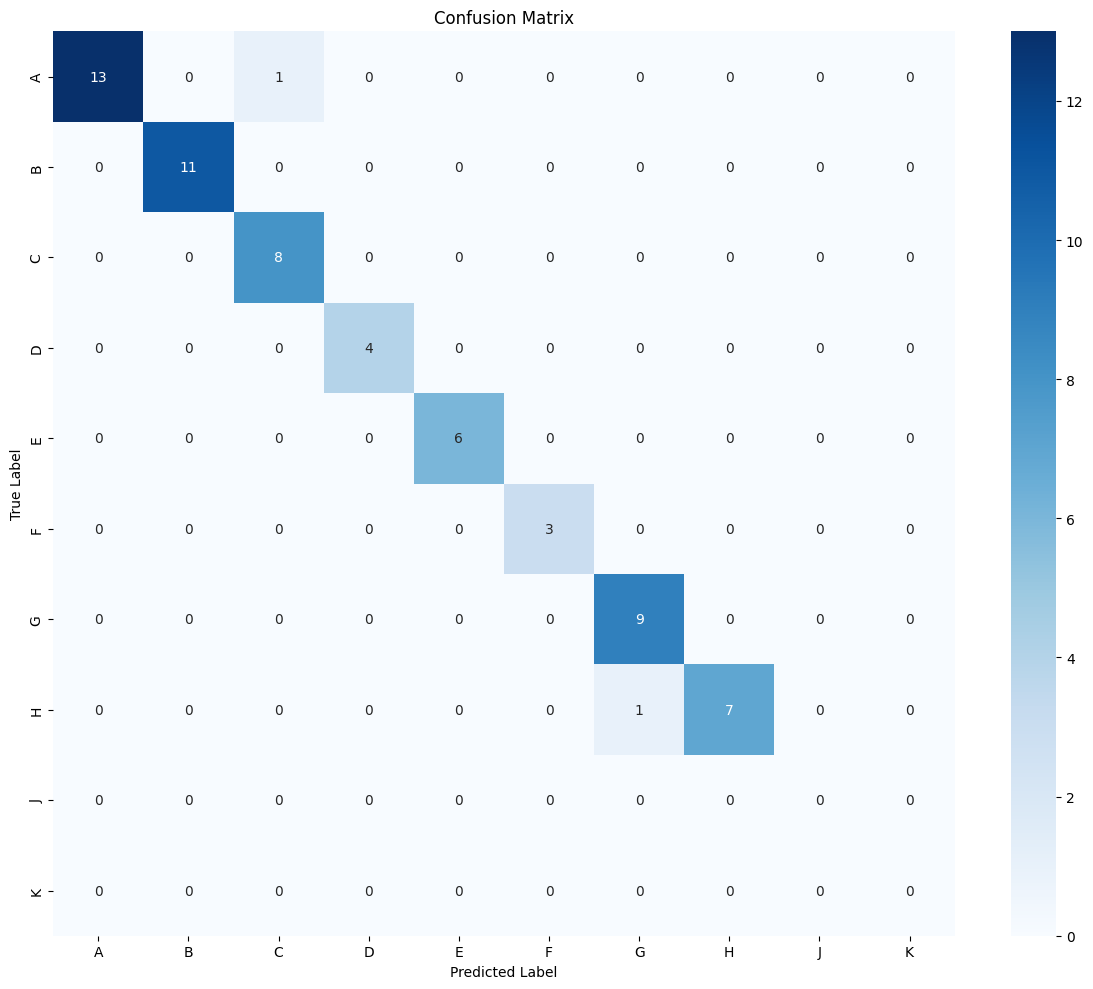

/var/folders/33/qr95pwt50dq4cf0070_f7g5c0000gn/T/ipykernel_54565/2982347575.py:50: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


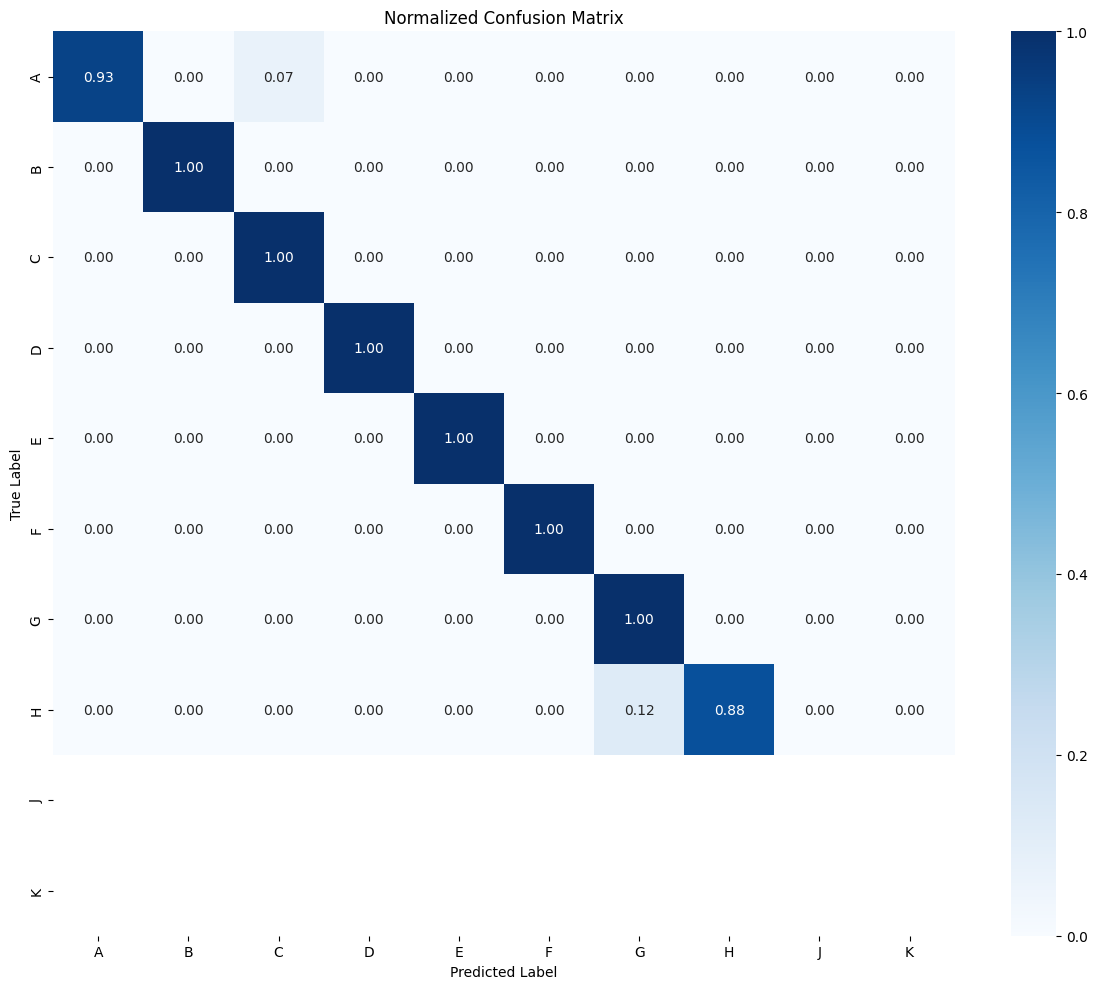


Feature Importance:
Feature 3: 25.4658
Feature 1: 24.9550
Feature 2: 24.8548
Feature 0: 24.7244


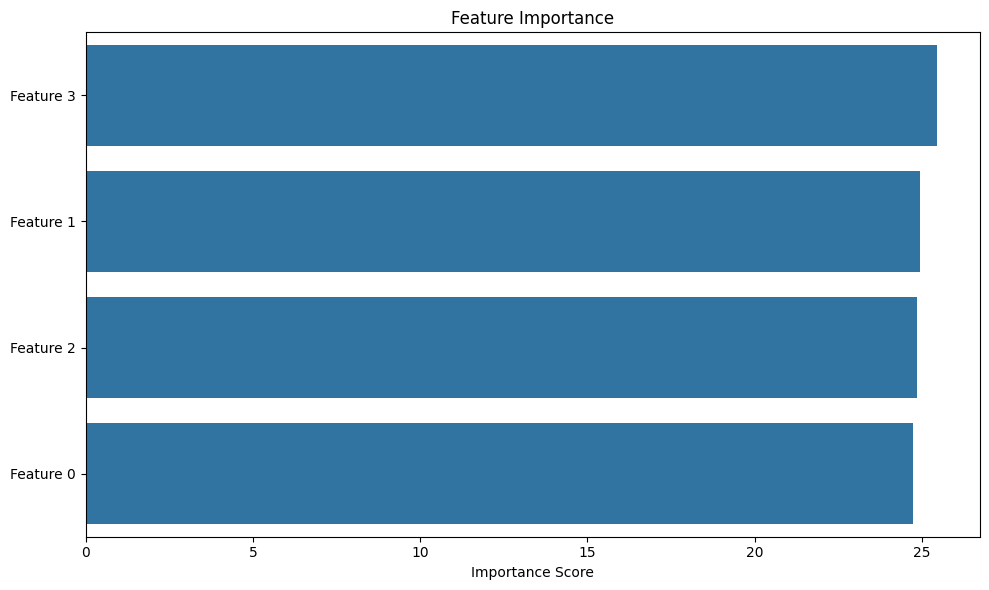

In [95]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming my_data and my_classes are already defined
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    my_data, my_classes, test_size=0.1, random_state=42
)

# Initialize the CatBoost classifier
model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=4,
    loss_function='MultiClass',
    random_seed=42,
    verbose=False
)

# Train the model
model.fit(my_data, my_classes)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Create and visualize the confusion matrix
class_names = sorted(np.unique(my_classes))
cm = confusion_matrix(y_test, y_pred, labels=class_names)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# Normalize the confusion matrix to show percentages
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('normalized_confusion_matrix.png')
plt.show()

# Feature importance
feature_importance = model.get_feature_importance()
feature_names = [f"Feature {i}" for i in range(my_data.shape[1])]
importance_df = sorted(zip(feature_names, feature_importance), key=lambda x: x[1], reverse=True)
print("\nFeature Importance:")
for feature, importance in importance_df:
    print(f"{feature}: {importance:.4f}")

# Plot feature importance
plt.figure(figsize=(10, 6))
importance_values = [imp for _, imp in importance_df]
importance_names = [name for name, _ in importance_df]
sns.barplot(x=importance_values, y=importance_names)
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# Save the model (optional)
model.save_model("catboost_classifier.cbm")

# Function to make predictions on new data
def predict_class(new_data):
    """
    Predict class for new data points
    
    Parameters:
    new_data: numpy array of shape (n_samples, 4)
    
    Returns:
    Predicted class labels
    """
    return model.predict(new_data)